# Statistical Arbitrage — Avellaneda & Lee (2008) Replication

An implementation of the PCA-based statistical arbitrage strategy from Avellaneda & Lee's "Statistical Arbitrage in the U.S. Equities Market" (2008), applied to the EURO STOXX 50 universe.

The strategy extracts systematic risk factors from stock returns via PCA, models the idiosyncratic residuals as mean-reverting Ornstein-Uhlenbeck processes, and trades a modified s-score signal built from those residuals. This notebook builds the pipeline end-to-end — factor model, O-U calibration, signal construction, rolling backtest with transaction costs and a proper signal-to-execution lag — then stress-tests it: sensitivity to the entry threshold and to the number of factors, a pre/post-2020 regime split, and a trading-time variant built on volume-adjusted returns.

It reuses the PCA utilities built in the companion notebook, [`01_covariance_estimation_and_factor_models.ipynb`](01_covariance_estimation_and_factor_models.ipynb).

In [1]:
# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.statistical_arbitrage import (
    estimate_factor_model,
    estimate_all_ou_parameters,
    estimate_ou_window_residuals,
    compute_s_score,
    compute_volume_adjusted_returns,
    update_positions,
    compute_strategy_statistics,
    compute_portfolio_weights,
)

In [2]:
# Reading the data
data_path = Path("data")

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
).ffill()

# Volume data for trading-time adjustment
volume = pd.read_csv(
    data_path / "volume.csv", index_col="Date", parse_dates=True
)

In [3]:
performance = last_prices.pct_change().iloc[1:]

In [4]:
# Parameters
estimation_window = 252  # 1 year of data for PCA factor model estimation
ou_estimation_window = 60  # 60 business days for O-U estimation
n_factors = 4  # Number of PCA factors

# Trading signal parameters
s_bo = 1.25  # Buy to open threshold
s_so = 1.25  # Sell to open threshold
s_bc = 0.50  # Buy to close threshold
s_sc = 0.50  # Sell to close threshold

# O-U filter
min_mean_reversion_speed = 8.4  # Minimum kappa for an asset to be tradable

min_coverage = 0.95
transaction_costs = 5e-4

# 1. Understanding PCA-based Factor Models

The statistical arbitrage approach by Avellaneda & Lee uses Principal Component Analysis (PCA) to extract systematic risk factors from stock returns. The idea is:

1. **Factor Model**: Decompose each stock's return as:
   $$R_{i,t} = \alpha_i + \sum_{j=1}^{K} \beta_{i,j} F_{j,t} + \epsilon_{i,t}$$

   where $F_j$ are the principal component factors.

2. **Residual Returns**: The residuals $\epsilon_{i,t}$ represent the idiosyncratic (stock-specific) returns.

3. **Mean Reversion**: The cumulative residuals $X_{i,t} = \sum_{s=1}^{t} \epsilon_{i,s}$ are modeled as mean-reverting Ornstein-Uhlenbeck processes.


In [5]:
# Example: Estimate factor model on the first estimation window
calibration_date = None
for date in performance.index:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=estimation_window,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == estimation_window and candidate_window.shape[1] > 0:
        calibration_date = date
        calibration_window = candidate_window
        break

print(
    f"First estimation window: {calibration_window.index[0].date()} to {calibration_window.index[-1].date()}"
)
print(f"Number of observations: {len(calibration_window)}")
print(f"Number of assets: {calibration_window.shape[1]}")

First estimation window: 2013-01-03 to 2013-12-24
Number of observations: 252
Number of assets: 46


In [6]:
# Estimate the factor model
factor_model = estimate_factor_model(candidate_window, n_factors=n_factors)

print(f"Number of factors used: {factor_model['n_factors']}")
print("\nExplained variance by each factor:")
for i, ev in enumerate(factor_model["explained_variance"]):
    print(f"  PC{i + 1}: {ev:.2%}")
print(f"\nTotal explained variance: {factor_model['explained_variance'].sum():.2%}")

Number of factors used: 4

Explained variance by each factor:
  PC1: 43.08%
  PC2: 5.75%
  PC3: 3.91%
  PC4: 2.71%

Total explained variance: 55.44%


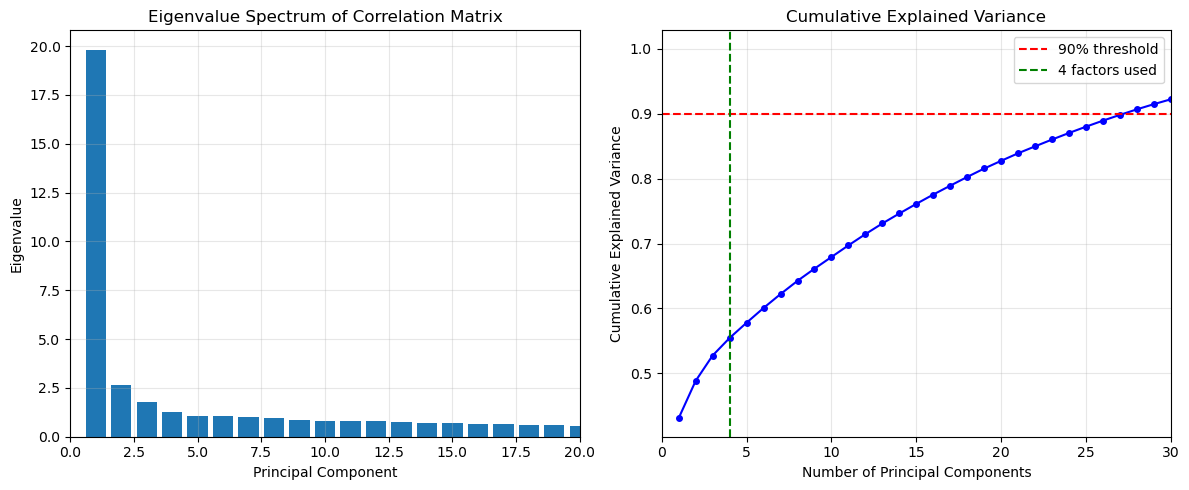

In [7]:
# Plot eigenvalue spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(factor_model["eigenvalues"]) + 1), factor_model["eigenvalues"])
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Correlation Matrix")
plt.xlim(0, 20)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_var = (
    np.cumsum(factor_model["eigenvalues"]) / factor_model["eigenvalues"].sum()
)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, "b-o", markersize=4)
plt.axhline(y=0.9, color="r", linestyle="--", label="90% threshold")
plt.axvline(x=n_factors, color="g", linestyle="--", label=f"{n_factors} factors used")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

# 2. Ornstein-Uhlenbeck Process for Residuals

The cumulative residuals are modeled as an Ornstein-Uhlenbeck (O-U) process:

$$dX_t = \kappa (m - X_t) dt + \sigma dW_t$$

where:

- $\kappa$ is the **mean-reversion speed** (how fast the process reverts to the mean)
- $m$ is the **equilibrium level** (long-term mean)
- $\sigma$ is the **volatility** of the process

The **equilibrium standard deviation** is: $\sigma_{eq} = \frac{\sigma}{\sqrt{2\kappa}}$

The **half-life** of mean reversion is: $\tau_{1/2} = \frac{\ln(2)}{\kappa}$


In [8]:
# Compute cumulative residuals
cumulative_residuals = estimate_ou_window_residuals(
    candidate_window, factor_model["factors"], ou_estimation_window
)["residuals"]

# Estimate O-U parameters
cum_residuals_ou = cumulative_residuals.iloc[-ou_estimation_window:]
ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)

# Display O-U parameters for a few assets
print(
    f"O-U Parameters for selected assets ({ou_estimation_window}-day window, centered means):"
)
print(f"{'Asset':<15} {'Kappa':>10} {'Half-life':>12} {'Sigma_eq':>12} {'m':>10}")
print("-" * 60)
for asset in list(ou_params.keys())[:10]:
    params = ou_params[asset]
    half_life_days = params["half_life"] * 252
    print(
        f"{asset:<15} {params['kappa']:>10.2f} {half_life_days:>10.1f} d {params['sigma_eq']:>12.4f} {params['m']:>10.4f}"
    )

O-U Parameters for selected assets (60-day window, centered means):
Asset                Kappa    Half-life     Sigma_eq          m
------------------------------------------------------------
ABI.BR               60.15        2.9 d       0.0100     0.0030
AD.AS                15.27       11.4 d       0.0302     0.0304
ADSGn.DE             16.83       10.4 d       0.0190     0.0210
AIR.PA               45.27        3.9 d       0.0235    -0.0129
AIRP.PA              28.12        6.2 d       0.0096    -0.0054
ALVG.DE              47.54        3.7 d       0.0080     0.0033
ASML.AS              19.00        9.2 d       0.0230    -0.0157
AXAF.PA              45.64        3.8 d       0.0134    -0.0079
BASFn.DE             18.33        9.5 d       0.0126     0.0141
BAYGn.DE            144.81        1.2 d       0.0072    -0.0071


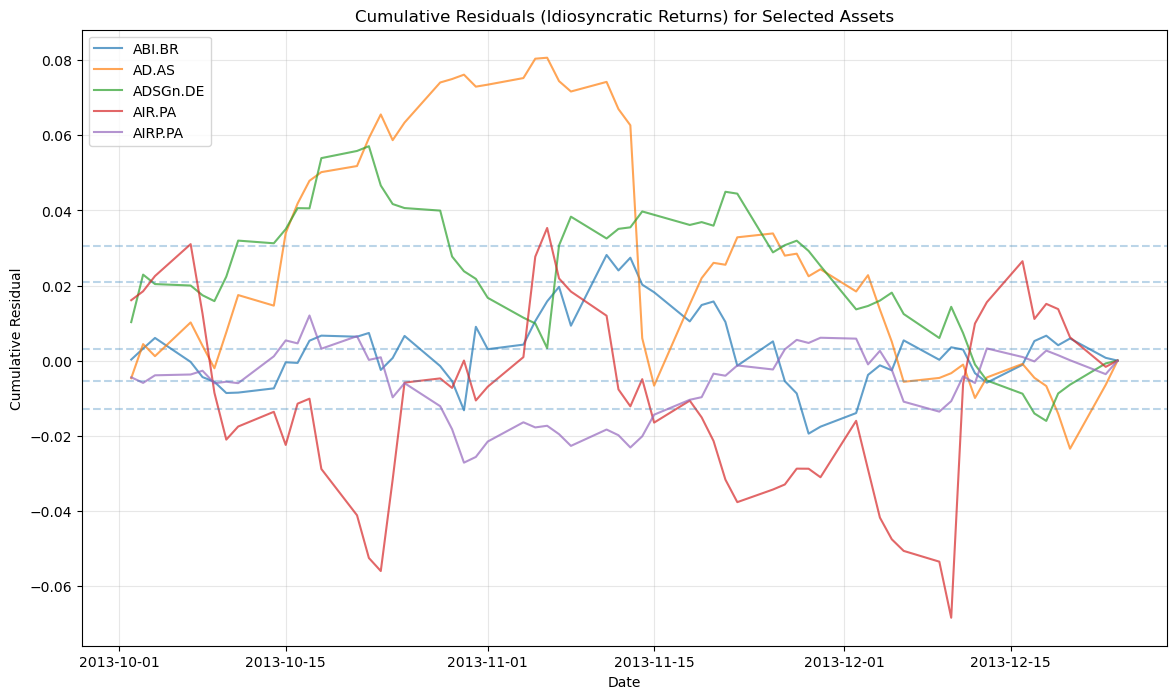

In [9]:
# Plot cumulative residuals for a few assets
sample_assets = list(cumulative_residuals.columns)[:5]

plt.figure(figsize=(14, 8))
for asset in sample_assets:
    plt.plot(
        cumulative_residuals.index, cumulative_residuals[asset], label=asset, alpha=0.7
    )
    # Add equilibrium level
    m = ou_params[asset]["m"]
    plt.axhline(y=m, linestyle="--", alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Cumulative Residual")
plt.title("Cumulative Residuals (Idiosyncratic Returns) for Selected Assets")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

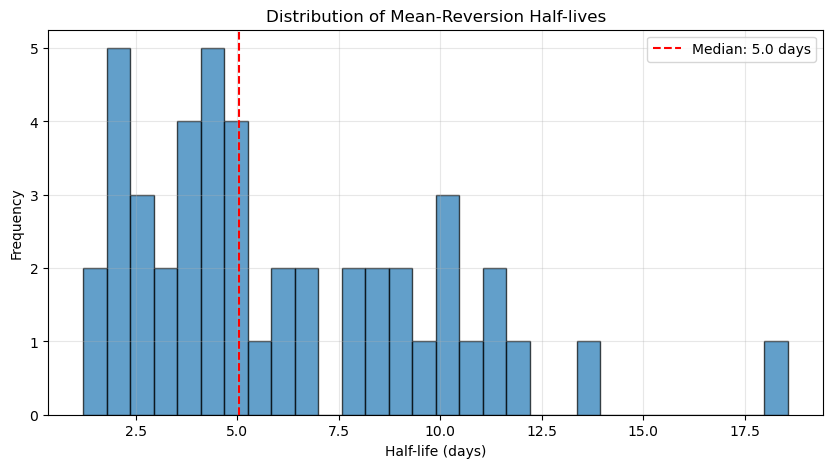

Half-life statistics:
  Mean: 6.2 days
  Median: 5.0 days
  Std: 3.8 days


In [10]:
# Distribution of half-lives
half_lives = pd.Series(
    {asset: params["half_life"] * 252 for asset, params in ou_params.items()}
)
half_lives = half_lives[half_lives < 100]  # Filter outliers

plt.figure(figsize=(10, 5))
plt.hist(half_lives, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Half-life (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean-Reversion Half-lives")
plt.axvline(
    half_lives.median(),
    color="r",
    linestyle="--",
    label=f"Median: {half_lives.median():.1f} days",
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Half-life statistics:")
print(f"  Mean: {half_lives.mean():.1f} days")
print(f"  Median: {half_lives.median():.1f} days")
print(f"  Std: {half_lives.std():.1f} days")

# 3. S-Score and Trading Signals

The modified **s-score** measures how far the current cumulative residual is from its equilibrium, accounting for the residual drift:

$$s_{mod, t} = s_t - \frac{\alpha}{\kappa \sigma_{eq}} =  \frac{X_t - m}{\sigma_{eq}} - \frac{\alpha}{\kappa \sigma_{eq}} $$

Trading rules:

- **Buy to Open** (enter long): $s < -s_{bo}$ (price is too low)
- **Sell to Close** (exit long): $s > -s_{bc}$ (price recovered)
- **Sell to Open** (enter short): $s > s_{so}$ (price is too high)
- **Buy to Close** (exit short): $s < s_{sc}$ (price reverted)


In [11]:
# Compute s-scores
s_scores = compute_s_score(cumulative_residuals, ou_params)

print("S-score statistics across all assets:")
print(
    f"  Mean: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].mean():.2f}"
)
print(
    f"  Std: {s_scores.values.flatten()[~np.isnan(s_scores.values.flatten())].std():.2f}"
)
print(f"  Min: {np.nanmin(s_scores.values):.2f}")
print(f"  Max: {np.nanmax(s_scores.values):.2f}")

S-score statistics across all assets:
  Mean: 0.00
  Std: 1.01
  Min: -2.76
  Max: 2.99


# 4. Rolling Backtest of Statistical Arbitrage Strategy

We now implement a rolling backtest where:

1. At each trading day, we re-estimate the factor model (252-day window) and O-U parameters (60-day window)
2. We compute s-scores and update trading positions **maintaining state across days**
3. We track the portfolio performance


In [12]:
# Storage for results
all_positions = {}
all_s_scores = {}
all_ou_params = {}
all_factor_models = {}

current_positions: dict[str, float] = {}

for rebalance_date in performance.index:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < estimation_window
        or cur_performance.shape[1] == 0
    ):
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    print(f"Processing: {reb_date}")

    # 1. Estimate factor model
    factor_model = estimate_factor_model(cur_performance, n_factors=n_factors)
    all_factor_models[reb_date] = factor_model

    # 2. Compute the residuals needed to estimate the mean-reversion parameters
    ou_window_results = estimate_ou_window_residuals(
    cur_performance, factor_model["factors"], ou_estimation_window
    )
    cum_residuals_ou = ou_window_results["residuals"].iloc[-ou_estimation_window:]
    alphas_ou = ou_window_results["alphas"] # We need alphas to compute the modified s-score, but we can also compute the basic s-score without them

    # 3. Estimate O-U parameters
    ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)
    all_ou_params[reb_date] = ou_params

    # 4. Filter assets
    valid_assets = [
        asset
        for asset, params in ou_params.items()
        if params["kappa"] >= min_mean_reversion_speed
    ]

    # 5. S-score
    cur_s_scores = compute_s_score(cum_residuals_ou, ou_params, modified=True, alphas=alphas_ou).iloc[-1]
    all_s_scores[reb_date] = cur_s_scores

    # Update positions carrying over previous day's state
    current_positions = update_positions(
        current_positions=current_positions,
        cur_s_scores=cur_s_scores, 
        valid_assets=valid_assets,
        s_bo=s_bo,
        s_so=s_so,
        s_bc=s_bc,
        s_sc=s_sc,
    )
    all_positions[reb_date] = current_positions.copy()

Processing: 2013-12-24
Processing: 2013-12-27


Processing: 2013-12-30
Processing: 2013-12-31
Processing: 2014-01-02
Processing: 2014-01-03
Processing: 2014-01-06
Processing: 2014-01-07
Processing: 2014-01-08
Processing: 2014-01-09
Processing: 2014-01-10
Processing: 2014-01-13


Processing: 2014-01-14
Processing: 2014-01-15
Processing: 2014-01-16


Processing: 2014-01-17
Processing: 2014-01-20
Processing: 2014-01-21
Processing: 2014-01-22
Processing: 2014-01-23
Processing: 2014-01-24
Processing: 2014-01-27
Processing: 2014-01-28
Processing: 2014-01-29
Processing: 2014-01-30
Processing: 2014-01-31


Processing: 2014-02-03
Processing: 2014-02-04
Processing: 2014-02-05
Processing: 2014-02-06


...

Processing: 2022-11-23
Processing: 2022-11-24
Processing: 2022-11-25
Processing: 2022-11-28
Processing: 2022-11-29
Processing: 2022-11-30
Processing: 2022-12-01
Processing: 2022-12-02
Processing: 2022-12-05
Processing: 2022-12-06
Processing: 2022-12-07
Processing: 2022-12-08
Processing: 2022-12-09


Processing: 2022-12-12
Processing: 2022-12-13
Processing: 2022-12-14
Processing: 2022-12-15
Processing: 2022-12-16
Processing: 2022-12-19
Processing: 2022-12-20
Processing: 2022-12-21
Processing: 2022-12-22
Processing: 2022-12-23
Processing: 2022-12-27
Processing: 2022-12-28


Processing: 2022-12-29
Processing: 2022-12-30
Processing: 2023-01-02
Processing: 2023-01-03
Processing: 2023-01-04
Processing: 2023-01-05
Processing: 2023-01-06
Processing: 2023-01-09
Processing: 2023-01-10
Processing: 2023-01-11


Processing: 2023-01-12
Processing: 2023-01-13
Processing: 2023-01-16
Processing: 2023-01-17
Processing: 2023-01-18
Processing: 2023-01-19
Processing: 2023-01-20
Processing: 2023-01-23
Processing: 2023-01-24
Processing: 2023-01-25
Processing: 2023-01-26
Processing: 2023-01-27
Processing: 2023-01-30


Processing: 2023-01-31
Processing: 2023-02-01
Processing: 2023-02-02
Processing: 2023-02-03
Processing: 2023-02-06
Processing: 2023-02-07
Processing: 2023-02-08
Processing: 2023-02-09
Processing: 2023-02-10
Processing: 2023-02-13
Processing: 2023-02-14
Processing: 2023-02-15
Processing: 2023-02-16
Processing: 2023-02-17


In [13]:
# Build portfolio weights time series
positions_df = pd.DataFrame(all_positions).T
positions_df.index = pd.to_datetime(positions_df.index)
positions_df = positions_df.fillna(0)

# Equal weight among active positions
weights = compute_portfolio_weights(positions_df)

print("Position statistics:")
print(f"  Total rebalance dates: {len(positions_df)}")
print(
    f"  Average number of long positions: {(positions_df > 0).sum(axis=1).mean():.1f}"
)
print(
    f"  Average number of short positions: {(positions_df < 0).sum(axis=1).mean():.1f}"
)
print(f"  Average total positions: {(positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics:
  Total rebalance dates: 2347
  Average number of long positions: 10.2
  Average number of short positions: 10.0
  Average total positions: 20.1


In [14]:
# Backtest the strategy
cumulative_returns = backtest(weights, performance)
cumulative_returns_with_costs = backtest(
    weights, performance, transaction_costs=transaction_costs
)

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns_with_costs.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

Strategy Performance:
  Total Return: 37.92%
  Annualized Return: 3.52%
  Annualized Volatility: 5.82%
  Sharpe Ratio: 0.60
  Maximum Drawdown: -9.65%
Strategy Performance:
  Total Return: 5.32%
  Annualized Return: 0.56%
  Annualized Volatility: 5.81%
  Sharpe Ratio: 0.10
  Maximum Drawdown: -13.32%


## 4.1 Cost Sensitivity Analysis

The 5 bps all-in cost is a default, not a verdict. We test a grid of [0, 2, 5, 10, 20] bps and locate the breakeven where the Sharpe collapses.

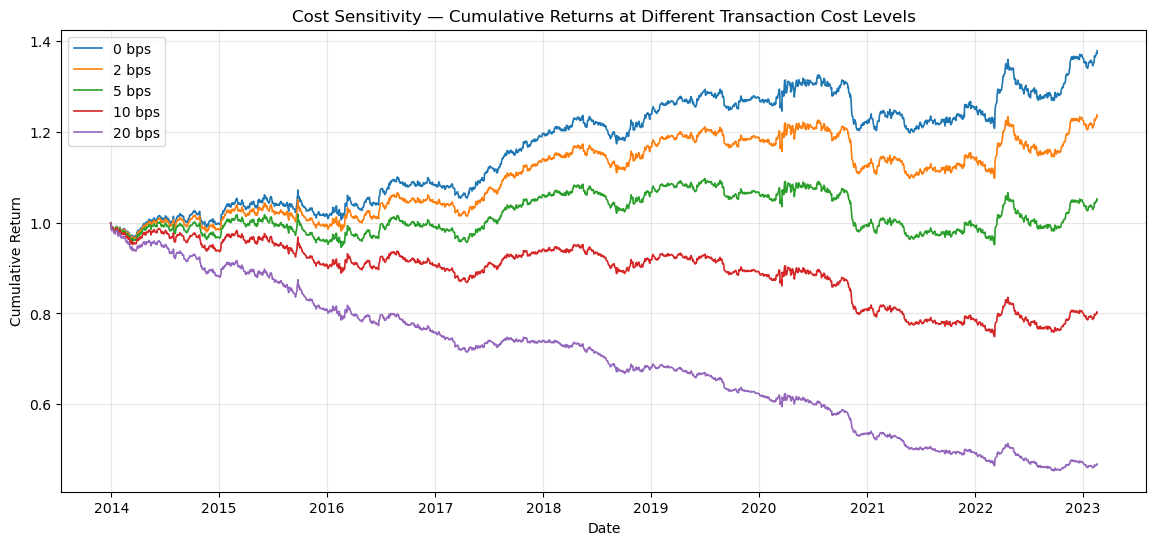

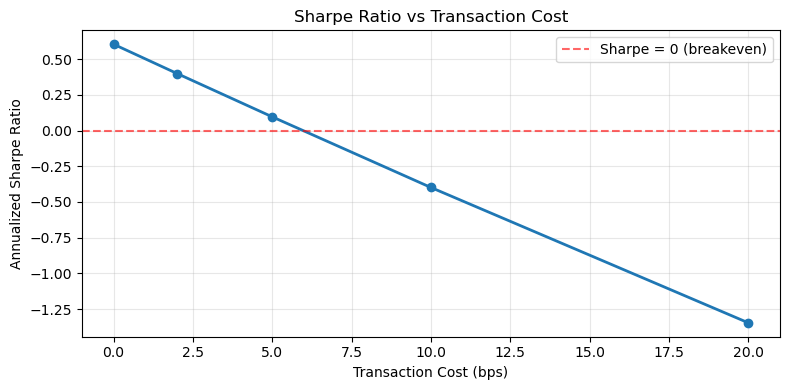


--- Cost Sensitivity Summary ---
           Total Return Ann. Return Ann. Vol Sharpe  Max DD
Cost (bps)                                                 
0                37.92%       3.52%    5.82%   0.60  -9.65%
2                23.81%       2.32%    5.81%   0.40 -10.45%
5                 5.32%       0.56%    5.81%   0.10 -13.32%
10              -19.58%      -2.32%    5.81%  -0.40 -25.02%
20              -53.12%      -7.82%    5.81%  -1.35 -54.57%


In [15]:
# Cost sensitivity grid: [0, 2, 5, 10, 20] bps
cost_levels_bps = [0, 2, 5, 10, 20]
cost_results = {}
cost_metrics = []

for bps in cost_levels_bps:
    tc_val = bps * 1e-4
    pnl = backtest(weights, performance, transaction_costs=tc_val)
    cost_results[bps] = pnl
    s = compute_strategy_statistics(pnl.dropna())
    cost_metrics.append({
        "Cost (bps)": bps,
        "Total Return": s["total_return"],
        "Ann. Return": s["annualized_return"],
        "Ann. Vol": s["annualized_volatility"],
        "Sharpe": s["sharpe_ratio"],
        "Max DD": s["max_drawdown"],
    })

# Plot equity curves
plt.figure(figsize=(14, 6))
for bps, pnl in cost_results.items():
    plt.plot(pnl, label=f"{bps} bps", linewidth=1.2)
plt.title("Cost Sensitivity — Cumulative Returns at Different Transaction Cost Levels")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Sharpe vs cost level
df_cost = pd.DataFrame(cost_metrics).set_index("Cost (bps)")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_cost.index, df_cost["Sharpe"], marker="o", linewidth=2)
ax.axhline(0, color="red", linestyle="--", alpha=0.6, label="Sharpe = 0 (breakeven)")
ax.set_xlabel("Transaction Cost (bps)")
ax.set_ylabel("Annualized Sharpe Ratio")
ax.set_title("Sharpe Ratio vs Transaction Cost")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Cost Sensitivity Summary ---")
print(df_cost.to_string(formatters={
    "Total Return": "{:.2%}".format,
    "Ann. Return":  "{:.2%}".format,
    "Ann. Vol":     "{:.2%}".format,
    "Sharpe":       "{:.2f}".format,
    "Max DD":       "{:.2%}".format,
}))

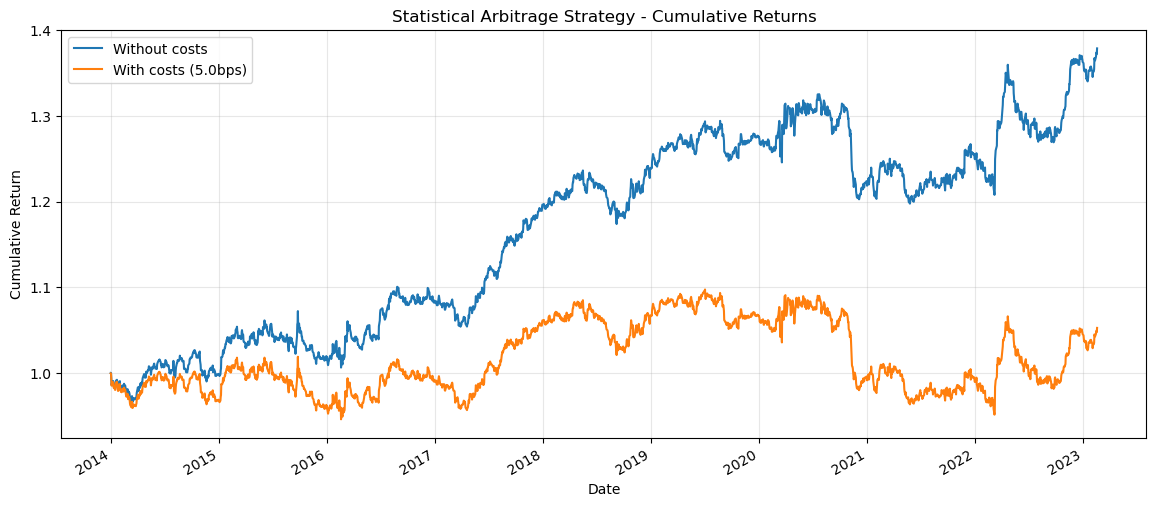

In [16]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Without costs", linewidth=1.5)
cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

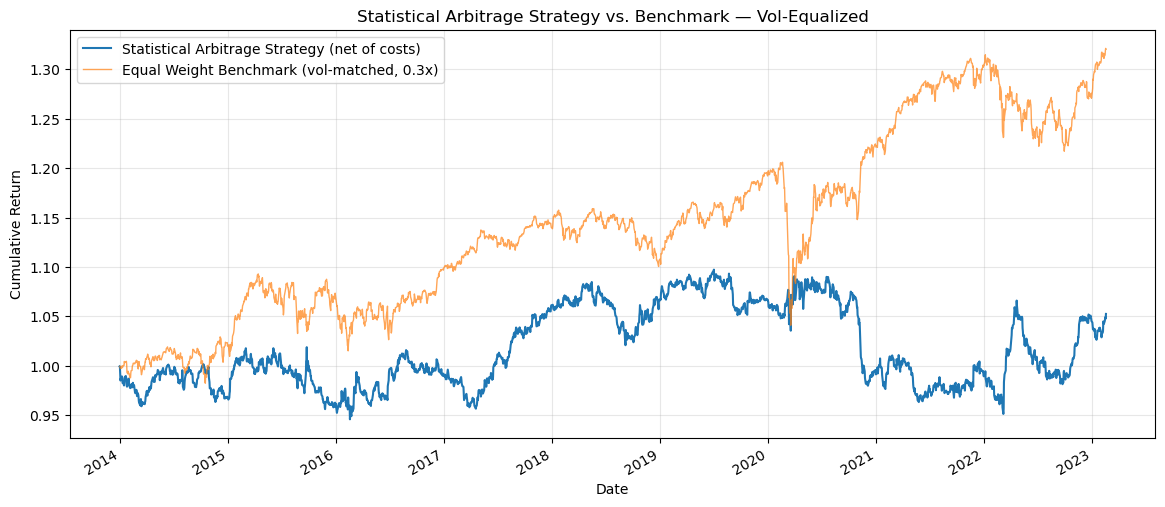

Sharpe ratio is the fair comparison — the two books carry different risk:
  Statistical Arbitrage (net of costs): Sharpe = 0.10, Ann. Vol = 5.81%
  Equal Weight Benchmark:               Sharpe = 0.47, Ann. Vol = 19.53%


In [17]:
# Compare the strategy to the benchmark on a like-for-like risk basis: the market-neutral
# book and the equal-weight benchmark carry different risk, so a face-value comparison of
# cumulative returns is not informative. We vol-equalize the benchmark to the strategy's
# realized volatility and lead with the Sharpe ratio.
equal_weight_benchmark = (1 + performance.mean(axis=1)).cumprod()
equal_weight_benchmark = equal_weight_benchmark.reindex(
    cumulative_returns_with_costs.index
).ffill()

strategy_returns = cumulative_returns_with_costs.pct_change().dropna()
benchmark_returns = equal_weight_benchmark.pct_change().dropna()
vol_scale = strategy_returns.std() / benchmark_returns.std()

benchmark_vol_matched = (1 + benchmark_returns * vol_scale).cumprod()
benchmark_vol_matched = (
    benchmark_vol_matched
    / benchmark_vol_matched.iloc[0]
    * cumulative_returns_with_costs.iloc[0]
)

plt.figure(figsize=(14, 6))
cumulative_returns_with_costs.plot(
    label="Statistical Arbitrage Strategy (net of costs)", linewidth=1.5
)
benchmark_vol_matched.plot(
    label=f"Equal Weight Benchmark (vol-matched, {vol_scale:.1f}x)", linewidth=1, alpha=0.7
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy vs. Benchmark — Vol-Equalized")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

strategy_stats = compute_strategy_statistics(cumulative_returns_with_costs.dropna())
benchmark_stats = compute_strategy_statistics(equal_weight_benchmark.dropna())

print("Sharpe ratio is the fair comparison — the two books carry different risk:")
print(
    f"  Statistical Arbitrage (net of costs): Sharpe = {strategy_stats['sharpe_ratio']:.2f}, "
    f"Ann. Vol = {strategy_stats['annualized_volatility']:.2%}"
)
print(
    f"  Equal Weight Benchmark:               Sharpe = {benchmark_stats['sharpe_ratio']:.2f}, "
    f"Ann. Vol = {benchmark_stats['annualized_volatility']:.2%}"
)

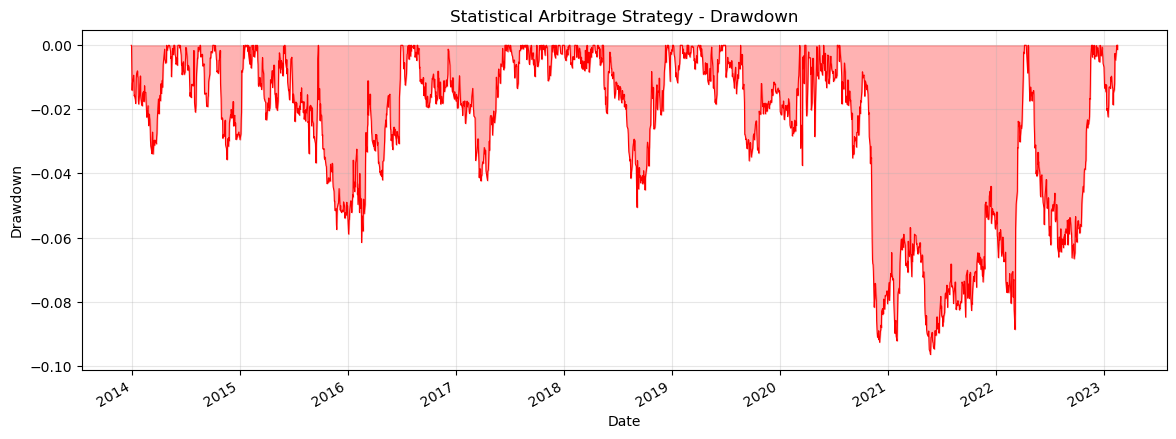

In [18]:
# Plot drawdown
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max

plt.figure(figsize=(14, 5))
drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Statistical Arbitrage Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

# 5. Analysis of Strategy Characteristics


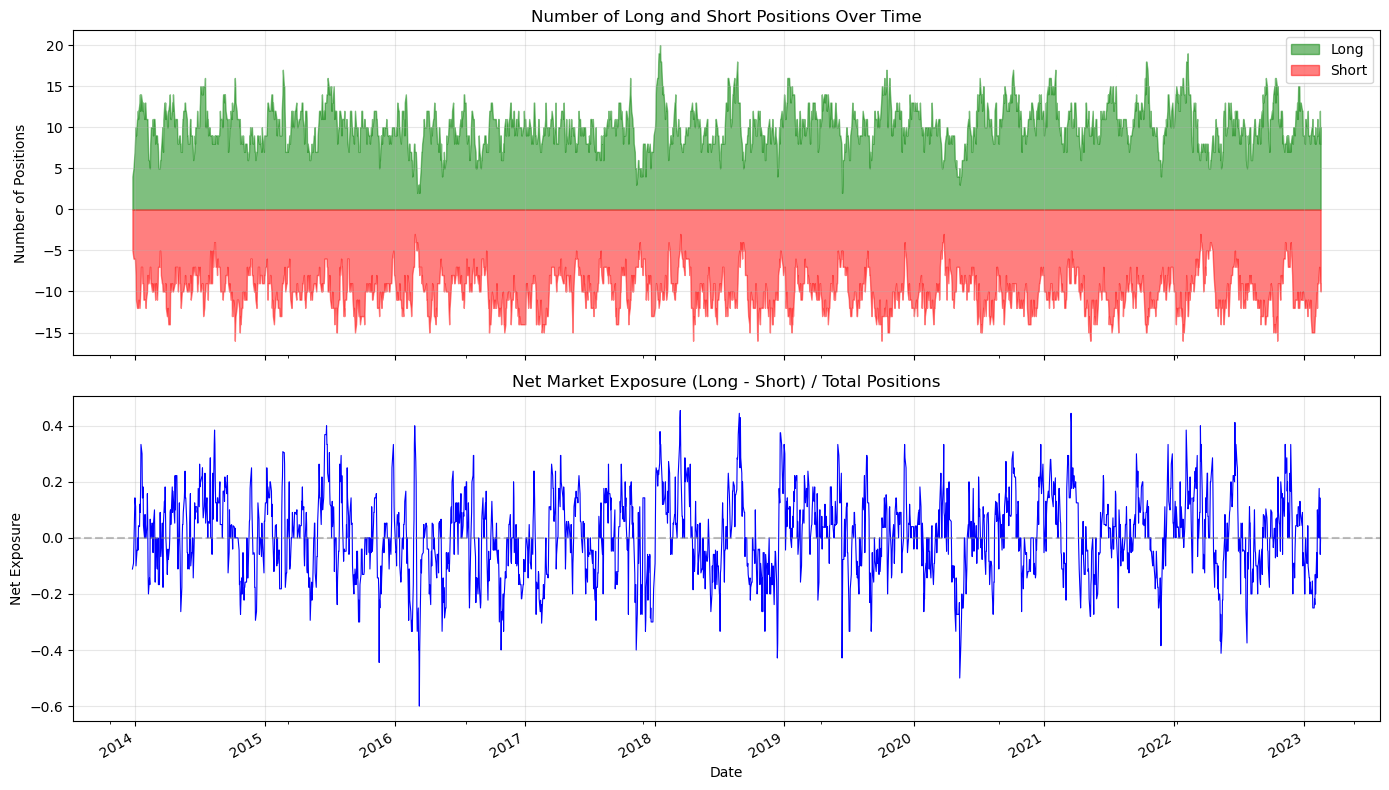

In [19]:
# Number of positions over time
n_long = (positions_df > 0).sum(axis=1)
n_short = (positions_df < 0).sum(axis=1)
n_total = (positions_df != 0).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(n_long.index, 0, n_long.values, color="green", alpha=0.5, label="Long")
ax1.fill_between(
    n_short.index, 0, -n_short.values, color="red", alpha=0.5, label="Short"
)
ax1.set_ylabel("Number of Positions")
ax1.set_title("Number of Long and Short Positions Over Time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
net_exposure = positions_df.sum(axis=1) / n_total.replace(0, np.nan)
net_exposure.plot(ax=ax2, color="blue", linewidth=0.8)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Net Exposure")
ax2.set_xlabel("Date")
ax2.set_title("Net Market Exposure (Long - Short) / Total Positions")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

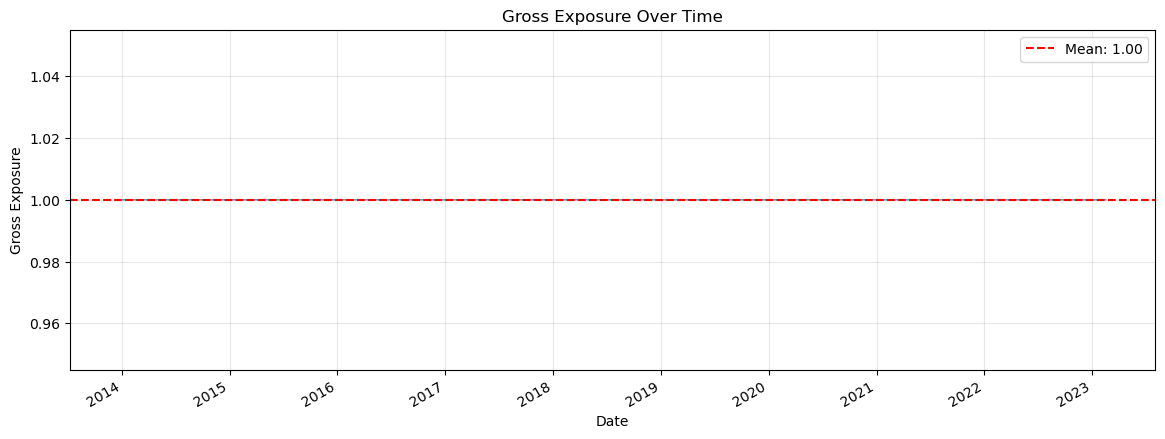

In [20]:
# Gross exposure over time
gross_exposure = weights.abs().sum(axis=1).round(6)

plt.figure(figsize=(14, 5))
gross_exposure.plot(linewidth=0.8)
plt.axhline(
    y=gross_exposure.mean(),
    color="r",
    linestyle="--",
    label=f"Mean: {gross_exposure.mean():.2f}",
)
plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

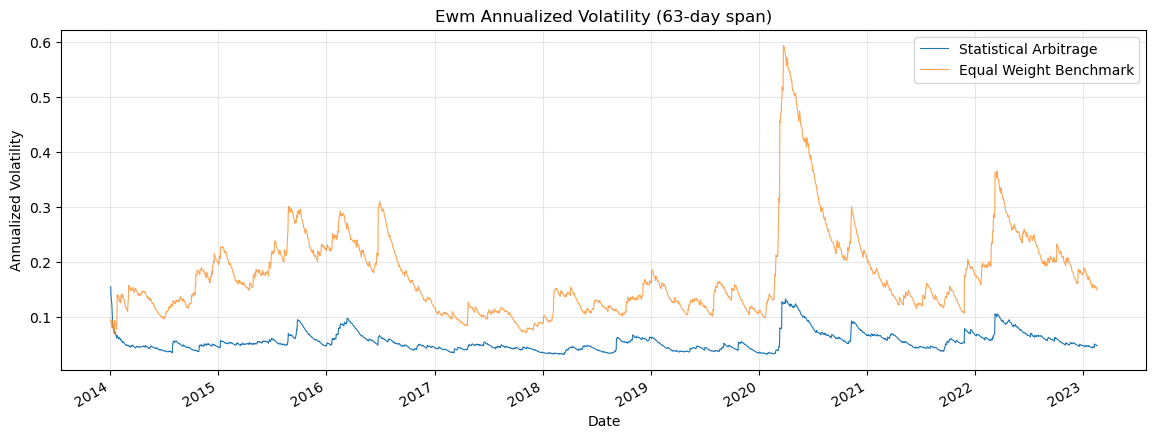

In [21]:
# Ewm volatility of strategy returns
strategy_returns = cumulative_returns.pct_change().dropna()
ewm_vol = strategy_returns.ewm(span=63).std() * np.sqrt(252)

benchmark_returns = equal_weight_benchmark.pct_change().dropna()
benchmark_ewm_vol = benchmark_returns.ewm(span=63).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
ewm_vol.plot(label="Statistical Arbitrage", linewidth=0.8)
benchmark_ewm_vol.plot(label="Equal Weight Benchmark", linewidth=0.8, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Ewm Annualized Volatility (63-day span)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Sensitivity Analysis

## 6.1 Sensitivity to s-score entry threshold


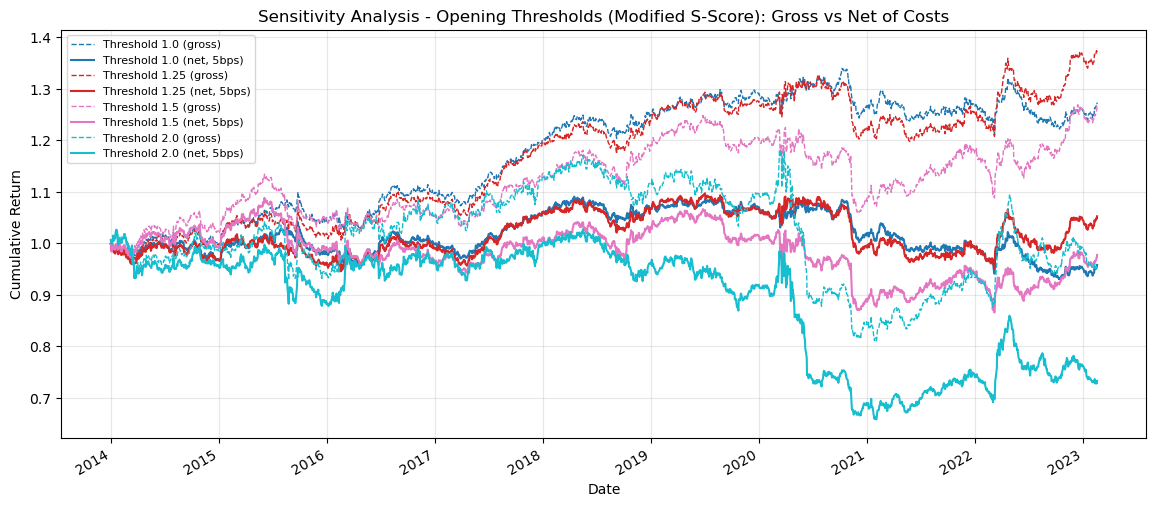


--- Sensitivity Analysis Summary ---
          Total Return Ann. Volatility Sharpe Ratio  Max Drawdown Total Return (gross) Sharpe Ratio (gross)
Threshold                                                                                                  
1.00            -4.12%           5.03%        -0.09     -0.147150               27.41%                 0.52
1.25             5.32%           5.81%         0.10     -0.133219               37.92%                 0.60
1.50            -2.15%           6.77%        -0.03     -0.204721               26.66%                 0.38
2.00           -27.21%           9.87%        -0.34     -0.359734               -5.00%                -0.06


In [22]:
# Sensitivity analysis parameters
opening_thresholds = [1.0, 1.25, 1.5, 2.0]
exit_level = 0.50  # symmetric exit thresholds
tc = 5e-4

# Storage for s-scores and valid assets across rebalance dates
all_s_scores_61 = {}
all_valid_assets_61 = {}

# Rolling estimation loop — same pipeline as the main backtest above
for rebalance_date in performance.index:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < estimation_window
        or cur_performance.shape[1] == 0
    ):
        continue

    # 1. Estimate factor model on the 252-day window
    factor_model = estimate_factor_model(cur_performance, n_factors=n_factors)

    # 2. Compute cumulative residuals on the last 60 days only
    # (OLS and cumsum are done inside estimate_ou_window_residuals)
    ou_window_results = estimate_ou_window_residuals(
        cur_performance, factor_model["factors"], ou_estimation_window
    )
    cum_residuals_ou = ou_window_results["residuals"].iloc[-ou_estimation_window:]
    alphas_ou = ou_window_results["alphas"]  # needed for the modified s-score's drift term

    # 3. Estimate O-U parameters
    ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252, center_ou_means=False)

    # 4. Filter assets by mean-reversion speed
    valid_assets = [
        asset
        for asset, params in ou_params.items()
        if params["kappa"] >= min_mean_reversion_speed
    ]

    # 5. Compute modified s-scores (includes drift term)
    cur_s_scores = compute_s_score(cum_residuals_ou, ou_params, modified=True, alphas=alphas_ou)

    all_s_scores_61[rebalance_date] = cur_s_scores.iloc[-1]  # signal for today
    all_valid_assets_61[rebalance_date] = valid_assets

# Run backtest separately for each threshold (reuses precomputed s-scores).
# Track both gross and net-of-cost PnL: higher thresholds cut turnover, so the
# cost-net Sharpe can stay flat even where the gross Sharpe declines.
threshold_results = {}
threshold_results_gross = {}
performance_metrics = []

for threshold in opening_thresholds:
    current_positions: dict[str, float] = {}
    all_positions = {}

    for date in all_s_scores_61:
        current_positions = update_positions(
            current_positions=current_positions,
            cur_s_scores=all_s_scores_61[date],
            valid_assets=all_valid_assets_61[date],
            s_bo=threshold,
            s_so=threshold,
            s_bc=exit_level,
            s_sc=exit_level,
        )
        all_positions[date] = current_positions.copy()

    # Build weights from positions
    positions_df = pd.DataFrame(all_positions).T
    positions_df.index = pd.to_datetime(positions_df.index)
    positions_df = positions_df.fillna(0)

    weights_df = compute_portfolio_weights(positions_df)

    # Note: no .shift(1) needed — backtest() shifts weights internally
    pnl_gross = backtest(portfolios=weights_df, returns=performance)
    pnl = backtest(portfolios=weights_df, returns=performance, transaction_costs=tc)
    threshold_results[threshold] = pnl
    threshold_results_gross[threshold] = pnl_gross

    # Compute statistics using the utility function
    stats = compute_strategy_statistics(pnl)
    stats_gross = compute_strategy_statistics(pnl_gross)

    performance_metrics.append({
        "Threshold": threshold,
        "Total Return": stats["total_return"],
        "Ann. Volatility": stats["annualized_volatility"],
        "Sharpe Ratio": stats["sharpe_ratio"],
        "Max Drawdown": stats["max_drawdown"],
        "Total Return (gross)": stats_gross["total_return"],
        "Sharpe Ratio (gross)": stats_gross["sharpe_ratio"],
    })

# Plot cumulative returns for each threshold — gross (dashed) vs net of costs (solid)
plt.figure(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(opening_thresholds)))
for color, threshold in zip(colors, opening_thresholds):
    threshold_results_gross[threshold].plot(
        label=f"Threshold {threshold} (gross)", linestyle="--", linewidth=1.0, color=color
    )
    threshold_results[threshold].plot(
        label=f"Threshold {threshold} (net, {tc * 1e4:.0f}bps)", linewidth=1.5, color=color
    )

plt.title("Sensitivity Analysis - Opening Thresholds (Modified S-Score): Gross vs Net of Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

# Print summary table
df_metrics = pd.DataFrame(performance_metrics).set_index("Threshold")
print("\n--- Sensitivity Analysis Summary ---")
print(df_metrics.to_string(formatters={
    "Total Return": "{:.2%}".format,
    "Ann. Volatility": "{:.2%}".format,
    "Sharpe Ratio": "{:.2f}".format,
    "Total Return (gross)": "{:.2%}".format,
    "Sharpe Ratio (gross)": "{:.2f}".format,
}))

## 6.2 Fixed factors vs variable factor selection


In [23]:
# ── 6.2  Variable number of PCs — target explained variance ────────────────
target_variances = [0.40, 0.55, 0.65, 0.75]
tc = 5e-4

# Reset to the baseline thresholds (section 6.1 swept these for its own sensitivity grid)
s_bo = 1.25
s_so = 1.25
s_bc = 0.50
s_sc = 0.50

# Storage — one entry per target level
var_positions      = {tv: {} for tv in target_variances}
var_current_pos    = {tv: {} for tv in target_variances}
n_factors_history  = {tv: {} for tv in target_variances}

dates_processed = 0

for rebalance_date in performance.index:
    cur_performance, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_performance.shape[1] == 0:
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    dates_processed += 1
    if dates_processed % 250 == 0:
        print(f"Processing: {reb_date}  ({dates_processed} dates done)")

    # Eigenvalues from the correlation matrix — computed ONCE per date
    eigenvalues_all = np.linalg.eigh(cur_performance.corr().values)[0][::-1]
    cum_var = np.cumsum(eigenvalues_all) / eigenvalues_all.sum()

    for target in target_variances:
        # Minimum number of PCs whose cumulative variance reaches target
        n_fac = int(np.searchsorted(cum_var, target)) + 1
        n_fac = max(1, min(n_fac, len(eigenvalues_all)))
        n_factors_history[target][reb_date] = n_fac

        # 1. Factor model with variable number of PCs
        factor_model = estimate_factor_model(cur_performance, n_factors=n_fac)

        # 2. Residuals on the 60-day OU window
        ou_result = estimate_ou_window_residuals(
            cur_performance, factor_model["factors"], ou_estimation_window
        )
        cum_residuals_ou = ou_result["residuals"].iloc[-ou_estimation_window:]
        alphas_ou = ou_result["alphas"]

        # 3. OU parameters
        ou_params = estimate_all_ou_parameters(
            cum_residuals_ou, dt=1 / 252, center_ou_means=False
        )

        # 4. Filter by mean-reversion speed
        valid_assets = [
            asset for asset, p in ou_params.items()
            if p["kappa"] >= min_mean_reversion_speed
        ]

        # 5. Modified s-score and position update
        cur_s = compute_s_score(
            cum_residuals_ou, ou_params, modified=True, alphas=alphas_ou
        )
        var_current_pos[target] = update_positions(
            current_positions=var_current_pos[target],
            cur_s_scores=cur_s.iloc[-1],
            valid_assets=valid_assets,
            s_bo=s_bo, s_so=s_so, s_bc=s_bc, s_sc=s_sc,
        )
        var_positions[target][reb_date] = var_current_pos[target].copy()

print(f"Done — {dates_processed} rebalance dates processed.")


# ── Backtest each target level ─────────────────────────────────────────────
var_results = {}
performance_metrics_62 = []

for target in target_variances:
    pos_df = pd.DataFrame(var_positions[target]).T
    pos_df.index = pd.to_datetime(pos_df.index)
    pos_df = pos_df.fillna(0)

    weights_var = compute_portfolio_weights(pos_df)
    pnl = backtest(weights_var, performance, transaction_costs=tc)
    var_results[target] = pnl

    # Compute statistics using the utility function
    stats = compute_strategy_statistics(pnl)

    performance_metrics_62.append({
        "Strategy": f"Variable ({target:.0%})",
        "Total Return": stats["total_return"],
        "Ann. Volatility": stats["annualized_volatility"],
        "Sharpe Ratio": stats["sharpe_ratio"],
    })

# Add the fixed 4-factor baseline, reusing the 6.1 results
performance_metrics_62.append({
    "Strategy": "Fixed (4 PCs)",
    "Total Return": df_metrics.loc[1.25, "Total Return"],
    "Ann. Volatility": df_metrics.loc[1.25, "Ann. Volatility"],
    "Sharpe Ratio": df_metrics.loc[1.25, "Sharpe Ratio"],
})

Processing: 2014-12-15  (250 dates done)


Processing: 2015-12-07  (500 dates done)


Processing: 2016-11-25  (750 dates done)


Processing: 2017-11-16  (1000 dates done)


Processing: 2018-11-08  (1250 dates done)


Processing: 2019-11-01  (1500 dates done)


Processing: 2020-10-26  (1750 dates done)


Processing: 2021-10-15  (2000 dates done)


Processing: 2022-10-04  (2250 dates done)


Done — 2347 rebalance dates processed.


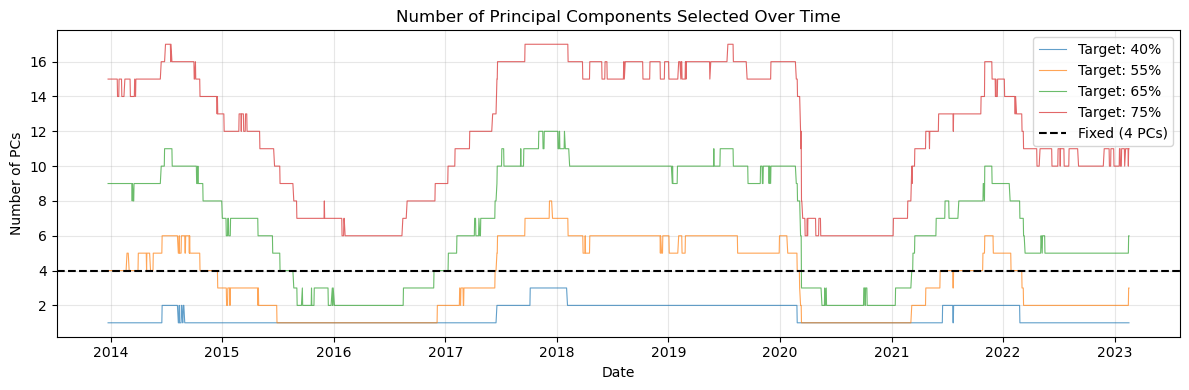

In [24]:
# ── Plot 1: Number of PCs selected over time ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for target in target_variances:
    series = pd.Series(n_factors_history[target])
    series.index = pd.to_datetime(series.index)
    ax.plot(series, label=f"Target: {target:.0%}", alpha=0.7, linewidth=0.8)
ax.axhline(y=4, color="black", linestyle="--", label="Fixed (4 PCs)")
ax.set_xlabel("Date")
ax.set_ylabel("Number of PCs")
ax.set_title("Number of Principal Components Selected Over Time")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


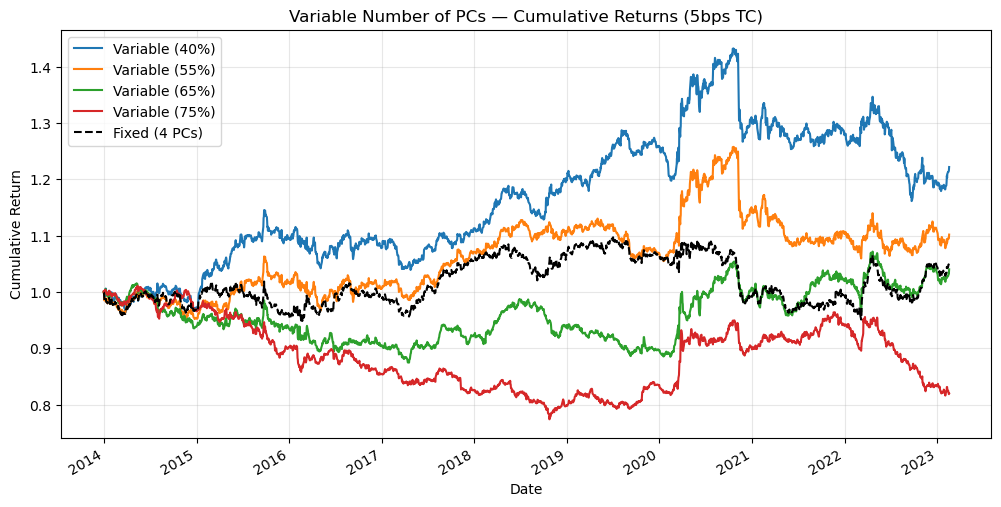


--- Variable PCs: Sensitivity Analysis Summary ---
               Total Return Ann. Volatility Sharpe Ratio
Strategy                                                
Variable (40%)       22.30%           6.86%         0.32
Variable (55%)       10.29%           6.49%         0.16
Variable (65%)        3.94%           5.82%         0.07
Variable (75%)      -18.13%           5.28%        -0.40
Fixed (4 PCs)         5.32%           5.81%         0.10


In [25]:
# ── Plot 1: Cumulative returns ─────────────────────────────────────────────
plt.figure(figsize=(12, 6))
for target, pnl in var_results.items():
    plt.plot(pnl, label=f"Variable ({target:.0%})")
cumulative_returns_with_costs.plot(
    label="Fixed (4 PCs)", linestyle="--", color="black", linewidth=1.5
)
plt.title("Variable Number of PCs — Cumulative Returns (5bps TC)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
df_metrics_62 = pd.DataFrame(performance_metrics_62).set_index("Strategy")
print("\n--- Variable PCs: Sensitivity Analysis Summary ---")
print(df_metrics_62.to_string(formatters={
    "Total Return": "{:.2%}".format,
    "Ann. Volatility": "{:.2%}".format,
    "Sharpe Ratio": "{:.2f}".format,
}))

### 6.2b Pre/Post-2020 Regime Analysis

Cross-sectional correlations spiked through Covid; the variance explained by the same K changed materially. We split the sample at 2020-01-01 to expose this regime dependence.

Average number of PCs selected by regime:
Target                    Pre-2020     Post-2020
------------------------------------------------
Variable (40%)                1.50          1.27
Variable (55%)                3.98          2.50
Variable (65%)                7.52          5.31
Variable (75%)               12.87         10.36

Sharpe ratio (gross, no TC) by regime:
                Pre-2020  Post-2020
Strategy                           
Variable (40%)      0.70      -0.10
Variable (55%)      0.21       0.12
Variable (65%)     -0.36       0.67
Variable (75%)     -0.66      -0.06
Fixed (4 PCs)       0.21      -0.05


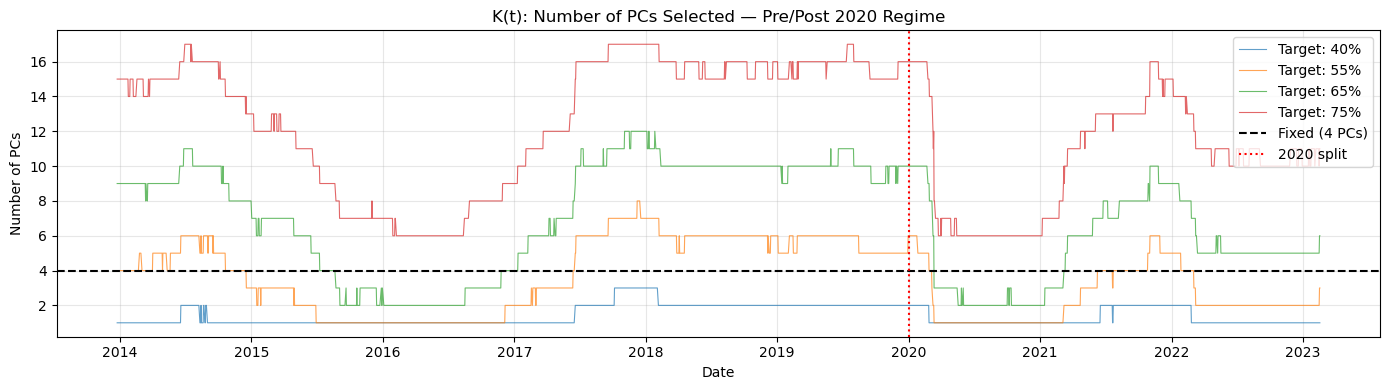

In [26]:
split_date = "2020-01-01"

regimes = {"Pre-2020": (None, split_date), "Post-2020": (split_date, None)}
regime_metrics = []

# K(t) mean per target per regime
print("Average number of PCs selected by regime:")
header = f"{'Target':<20}" + "".join(f"  {r:>12}" for r in regimes)
print(header)
print("-" * len(header))
for target in target_variances:
    series = pd.Series(n_factors_history[target])
    series.index = pd.to_datetime(series.index)
    row = f"{f'Variable ({target:.0%})':<20}"
    for regime, (start, end) in regimes.items():
        subset = series.loc[start:end]
        row += f"  {subset.mean():>12.2f}"
    print(row)

print()

# Sharpe per strategy per regime
print("Sharpe ratio (gross, no TC) by regime:")
all_pnls = {f"Variable ({t:.0%})": var_results[t] for t in target_variances}
all_pnls["Fixed (4 PCs)"] = cumulative_returns_with_costs

regime_rows = []
for label, pnl in all_pnls.items():
    row = {"Strategy": label}
    for regime, (start, end) in regimes.items():
        sub = pnl.loc[start:end].dropna()
        if len(sub) > 5:
            row[regime] = compute_strategy_statistics(sub)["sharpe_ratio"]
        else:
            row[regime] = float("nan")
    regime_rows.append(row)

df_regime = pd.DataFrame(regime_rows).set_index("Strategy")
print(df_regime.to_string(float_format="{:.2f}".format))

# Plot K(t) with vertical split line
fig, ax = plt.subplots(figsize=(14, 4))
for target in target_variances:
    series = pd.Series(n_factors_history[target])
    series.index = pd.to_datetime(series.index)
    ax.plot(series, label=f"Target: {target:.0%}", alpha=0.7, linewidth=0.8)
ax.axhline(y=4, color="black", linestyle="--", label="Fixed (4 PCs)")
ax.axvline(pd.Timestamp(split_date), color="red", linestyle=":", linewidth=1.5, label="2020 split")
ax.set_xlabel("Date")
ax.set_ylabel("Number of PCs")
ax.set_title("K(t): Number of PCs Selected — Pre/Post 2020 Regime")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7 Trading Time: Volume-Adjusted Returns

### Trading Time

The paper proposes measuring returns in **trading time** rather than calendar time.
The idea: price moves on low-volume days carry more information than moves on high-volume days.

The adjusted return:

$$\bar{R}_{i,t} = R_{i,t} \cdot \frac{\langle \delta V_i \rangle}{V_{i,t}}$$

where $\langle \delta V_i \rangle$ is the trailing average daily volume and $V_{i,t}$ is the actual volume on day $t$.

This amplifies price moves on quiet days and dampens moves on heavy-volume days.
We run the full backtest pipeline on these adjusted returns and compare to calendar time.


In [27]:
vol_adjusted_returns = compute_volume_adjusted_returns(
    returns=performance,
    volume=volume,
    trailing_window=ou_estimation_window,  # 60 days, same as OU window
)

Rolling backtest on volume-adjusted returns

In [28]:
# Storage for results
vol_all_positions = {}
vol_current_positions: dict[str, float] = {}

for rebalance_date in vol_adjusted_returns.index:
    cur_performance_vol, cur_diag_vol = prepare_rolling_estimation_window(
        returns=vol_adjusted_returns,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_diag_vol["row_count"] < estimation_window
        or cur_performance_vol.shape[1] == 0
    ):
        continue

    # 1. Estimate factor model on the 252-day window
    vol_factor_model = estimate_factor_model(cur_performance_vol, n_factors=n_factors)

    # 2. Compute cumulative residuals on the last 60 days only
    vol_ou_results = estimate_ou_window_residuals(
        cur_performance_vol, vol_factor_model["factors"], ou_estimation_window
    )
    vol_cum_residuals = vol_ou_results["residuals"].iloc[-ou_estimation_window:]
    vol_alphas = vol_ou_results["alphas"]  # needed for modified s-score (formula 17)

    # 3. Estimate O-U parameters
    vol_ou_params = estimate_all_ou_parameters(
        vol_cum_residuals, dt=1 / 252, center_ou_means=False
    )

    # 4. Filter assets by mean-reversion speed
    vol_valid_assets = [
        asset
        for asset, params in vol_ou_params.items()
        if params["kappa"] >= min_mean_reversion_speed
    ]

    # 5. Compute modified s-scores (includes drift term)
    vol_s_scores = compute_s_score(
        vol_cum_residuals, vol_ou_params, modified=True, alphas=vol_alphas
    )

    # Update positions carrying over previous day's state
    vol_current_positions = update_positions(
        current_positions=vol_current_positions,
        cur_s_scores=vol_s_scores.iloc[-1],
        valid_assets=vol_valid_assets,
        s_bo=s_bo,
        s_so=s_so,
        s_bc=s_bc,
        s_sc=s_sc,
    )
    vol_all_positions[rebalance_date] = vol_current_positions.copy()

In [29]:
# Build portfolio weights time series
vol_positions_df = pd.DataFrame(vol_all_positions).T
vol_positions_df.index = pd.to_datetime(vol_positions_df.index)
vol_positions_df = vol_positions_df.fillna(0)

vol_weights = compute_portfolio_weights(vol_positions_df)

print("Position statistics (volume-adjusted):")
print(f"  Total rebalance dates: {len(vol_positions_df)}")
print(f"  Average number of long positions: {(vol_positions_df > 0).sum(axis=1).mean():.1f}")
print(f"  Average number of short positions: {(vol_positions_df < 0).sum(axis=1).mean():.1f}")
print(f"  Average total positions: {(vol_positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics (volume-adjusted):
  Total rebalance dates: 2288
  Average number of long positions: 9.9
  Average number of short positions: 9.8
  Average total positions: 19.7


In [30]:
# Backtest — positions from vol-adjusted signals, returns are ORIGINAL (real prices)
vol_cumulative_returns = backtest(vol_weights, performance)
vol_cumulative_returns_with_costs = backtest(
    vol_weights, performance, transaction_costs=transaction_costs
)

# Compute strategy statistics
vol_stats = compute_strategy_statistics(vol_cumulative_returns_with_costs.dropna())

print("Strategy Performance (Trading Time, 5bps TC):")
print(f"  Total Return: {vol_stats['total_return']:.2%}")
print(f"  Annualized Return: {vol_stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {vol_stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {vol_stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {vol_stats['max_drawdown']:.2%}")

Strategy Performance (Trading Time, 5bps TC):
  Total Return: -14.06%
  Annualized Return: -1.66%
  Annualized Volatility: 6.06%
  Sharpe Ratio: -0.27
  Maximum Drawdown: -19.38%


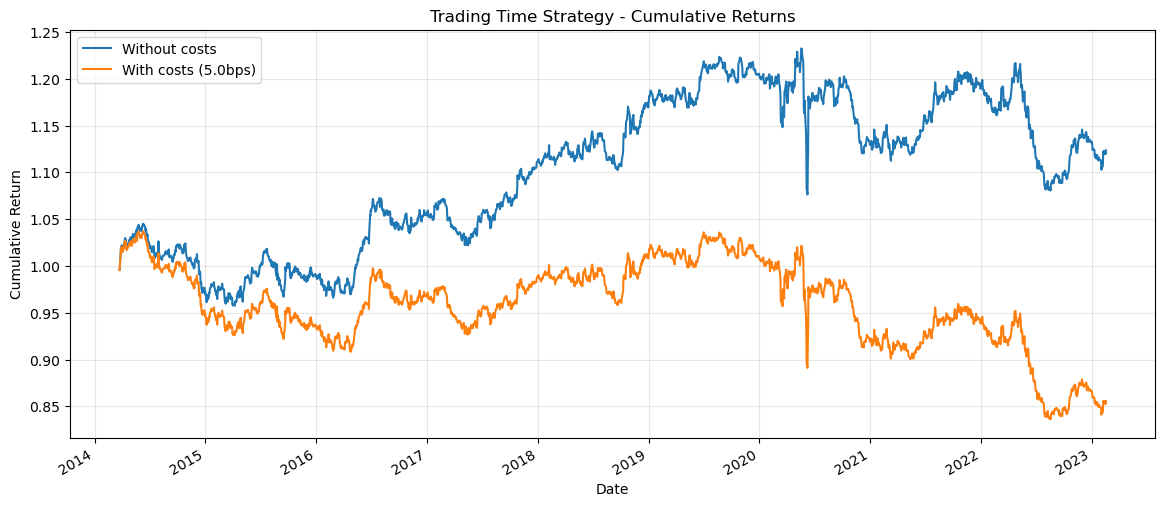

In [31]:
# Plot cumulative returns — with and without transaction costs
plt.figure(figsize=(14, 6))
vol_cumulative_returns.plot(label="Without costs", linewidth=1.5)
vol_cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Trading Time Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

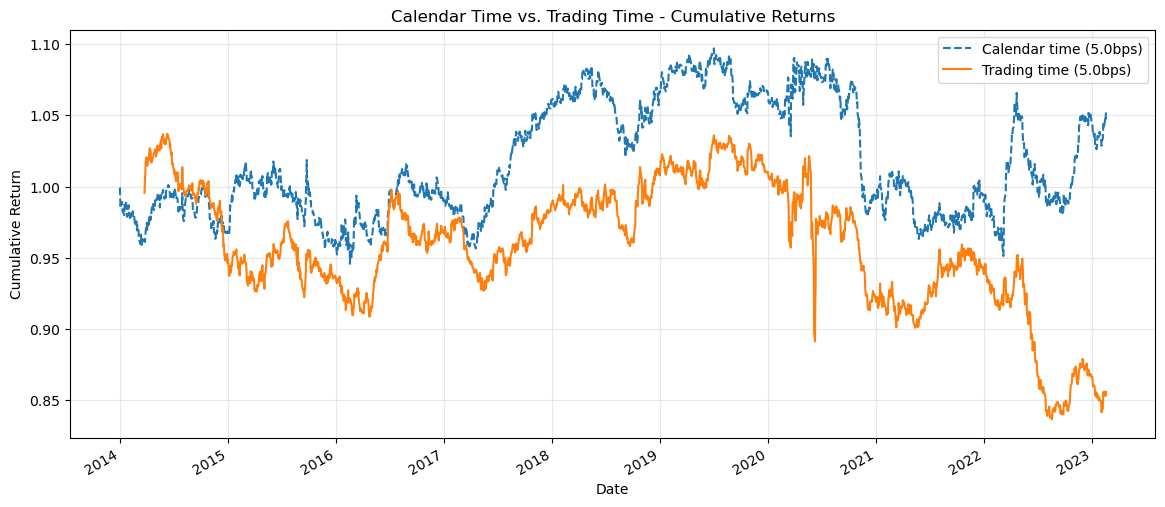

In [32]:
# Compare calendar time vs trading time (both with 5bps TC)
plt.figure(figsize=(14, 6))
cumulative_returns_with_costs.plot(
    label=f"Calendar time ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5, linestyle="--"
)
vol_cumulative_returns_with_costs.plot(
    label=f"Trading time ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Calendar Time vs. Trading Time - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

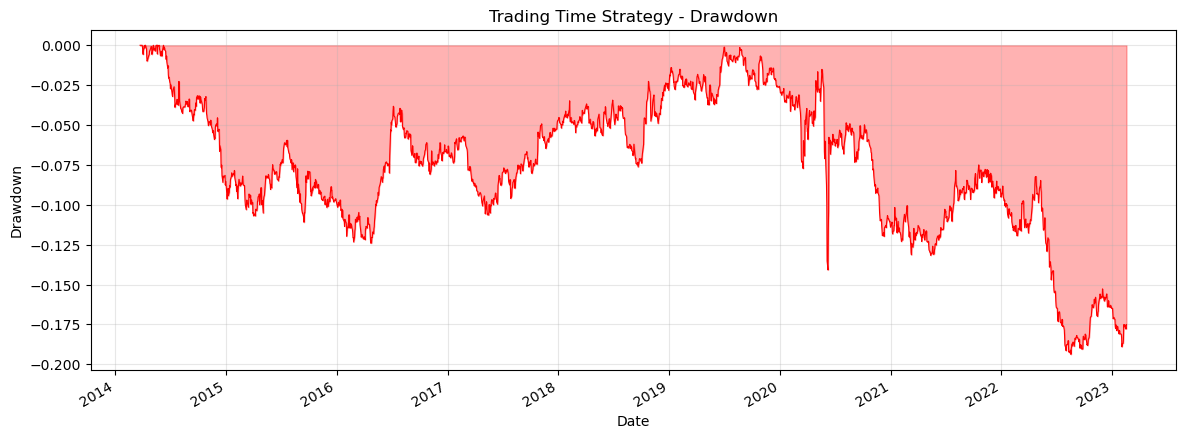

In [33]:
# Plot drawdown
vol_rolling_max = vol_cumulative_returns_with_costs.cummax()
vol_drawdown = (vol_cumulative_returns_with_costs - vol_rolling_max) / vol_rolling_max

plt.figure(figsize=(14, 5))
vol_drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(vol_drawdown.index, 0, vol_drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Trading Time Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

Performance comparison

In [34]:
# Side-by-side statistics: calendar time vs trading time (both with 5bps TC)
baseline_stats = compute_strategy_statistics(cumulative_returns_with_costs.dropna())

print("Performance Comparison — Calendar Time vs. Trading Time (5bps TC):")
print(f"{'Metric':<25} {'Calendar Time':>15} {'Trading Time':>15}")
print("-" * 57)
for metric, label in [
    ("total_return",          "Total Return"),
    ("annualized_return",     "Ann. Return"),
    ("annualized_volatility", "Ann. Volatility"),
    ("sharpe_ratio",          "Sharpe Ratio"),
    ("max_drawdown",          "Max Drawdown"),
]:
    fmt = "{:.2%}" if metric != "sharpe_ratio" else "{:.2f}"
    print(
        f"{label:<25} {fmt.format(baseline_stats[metric]):>15} {fmt.format(vol_stats[metric]):>15}"
    )

Performance Comparison — Calendar Time vs. Trading Time (5bps TC):
Metric                      Calendar Time    Trading Time
---------------------------------------------------------
Total Return                        5.32%         -14.06%
Ann. Return                         0.56%          -1.66%
Ann. Volatility                     5.81%           6.06%
Sharpe Ratio                         0.10           -0.27
Max Drawdown                      -13.32%         -19.38%
